In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from torch import device, cuda, nn , no_grad, tensor,load,save, sigmoid , cat , float32
from torch.utils.data import Dataset,DataLoader,Subset
from torchvision.utils import make_grid
from torchvision.models import densenet121,resnet50,efficientnet_v2_m,vit_b_16,swin_v2_t,DenseNet121_Weights,ResNet50_Weights,EfficientNet_V2_M_Weights,ViT_B_16_Weights,Swin_V2_T_Weights
import torchvision.transforms as transforms
from torch.optim import AdamW
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import roc_auc_score,f1_score, precision_score, recall_score,multilabel_confusion_matrix,ConfusionMatrixDisplay
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")

%matplotlib inline

dev = device("cuda" if cuda.is_available() else "cpu")
dev

device(type='cuda')

In [3]:
checkpoint = load("data_essentials.pth",map_location=dev,weights_only=False)
checkpoint.keys()

dict_keys(['train_df', 'val_df', 'test_df', 'all_diseases', 'img_folders', 'num_of_classes', 'pos_weights'])

In [ ]:
SAVED_MODELS_FOLDER = r"C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\My Reserch Papers\chest-xray-multilabel-classification\saved_models"

IMG_FOLDERS = checkpoint["img_folders"]

NUM_OF_CLASSES = checkpoint["num_of_classes"]

ALL_DISEASES = checkpoint["all_diseases"]

BATCH_SIZE = 64
MEAN_NORM = [0.485, 0.456, 0.406]
STD_NORM = [0.229, 0.224, 0.225]

POS_WEIGHTS = checkpoint["pos_weights"]

EPOCHS = 10
PATIENCE = 5
BEST_VAL_AUC = 0.0

LR = 1e-4

train_df = checkpoint["train_df"]
val_df = checkpoint["val_df"]
test_df = checkpoint["test_df"]

In [5]:
def get_transforms(size=224 , In_Train=True):
    if In_Train:
        return transforms.Compose([transforms.Resize((size,size)),
                                   transforms.RandomRotation(10),
                                   transforms.RandomHorizontalFlip(),
                                   transforms.ColorJitter(brightness=0.1, contrast=0.1),
                                   transforms.ToTensor(),
                                   transforms.Normalize(mean=MEAN_NORM,
                                                        std=STD_NORM)])
    else:
        return transforms.Compose([transforms.Resize((size,size)),
                                   transforms.ToTensor(),
                                   transforms.Normalize(mean=MEAN_NORM,
                                                        std=STD_NORM)])

In [6]:
class ChestXRayDataset(Dataset):
    def __init__(self,df,img_folders,transforms=None):
        self.df = df.reset_index(drop=True)
        self.img_folders = img_folders
        self.transforms = transforms
        self.labels = self._encode_labels()

    def _encode_labels(self):
        encode = []

        for label in self.df["Finding Labels"]:
            diseases_in_img = label.split("|")

            vector = [0.0] * NUM_OF_CLASSES
            for disease in diseases_in_img:
                if disease in ALL_DISEASES:
                    idx = ALL_DISEASES.index(disease)
                    vector[idx] = 1.0
            encode.append(vector)
        return encode
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        img_name = self.df.loc[index,"Image Index"]

        img = None
        for folder in IMG_FOLDERS:
            img_path = os.path.join(folder,img_name)
            if os.path.exists(img_path):
                img = Image.open(img_path).convert("RGB")
                break
        
        if self.transforms:
            img = self.transforms(img)

        label = tensor(self.labels[index],dtype=float32)
        return img,label


train_dataset = ChestXRayDataset(train_df,IMG_FOLDERS,transforms=get_transforms())
val_dataset = ChestXRayDataset(val_df,IMG_FOLDERS,get_transforms(In_Train=False))
test_dataset = ChestXRayDataset(test_df,IMG_FOLDERS,get_transforms(In_Train=False))

eff_train_dataset = ChestXRayDataset(train_df,IMG_FOLDERS,get_transforms(384))
eff_val_dataset = ChestXRayDataset(val_df,IMG_FOLDERS,get_transforms(384,In_Train=False))
eff_test_dataset = ChestXRayDataset(test_df,IMG_FOLDERS,get_transforms(384,In_Train=False))

swin_train_dataset = ChestXRayDataset(train_df,IMG_FOLDERS,get_transforms(256))
swin_val_dataset = ChestXRayDataset(val_df,IMG_FOLDERS,get_transforms(256,In_Train=False))
swin_test_dataset = ChestXRayDataset(test_df,IMG_FOLDERS,get_transforms(256,In_Train=False))

In [7]:
train_dl = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_dl = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

eff_train_dl = DataLoader(eff_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
eff_val_dl = DataLoader(eff_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
eff_test_dl = DataLoader(eff_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

swin_train_dl = DataLoader(swin_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
swin_val_dl = DataLoader(swin_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
swin_test_dl = DataLoader(swin_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

In [8]:
def denormalize(data):

    
    mean = tensor(MEAN_NORM).to(data.device)
    std = tensor(STD_NORM).to(data.device)

    
    if data.ndimension() == 3:
        
        res = data * std[:, None, None] + mean[:, None, None]
        
    
    elif data.ndimension() == 4:
       
        res = data * std[None, :, None, None] + mean[None, :, None, None]
    
    else:
        return data 

    return res.clamp(0, 1)

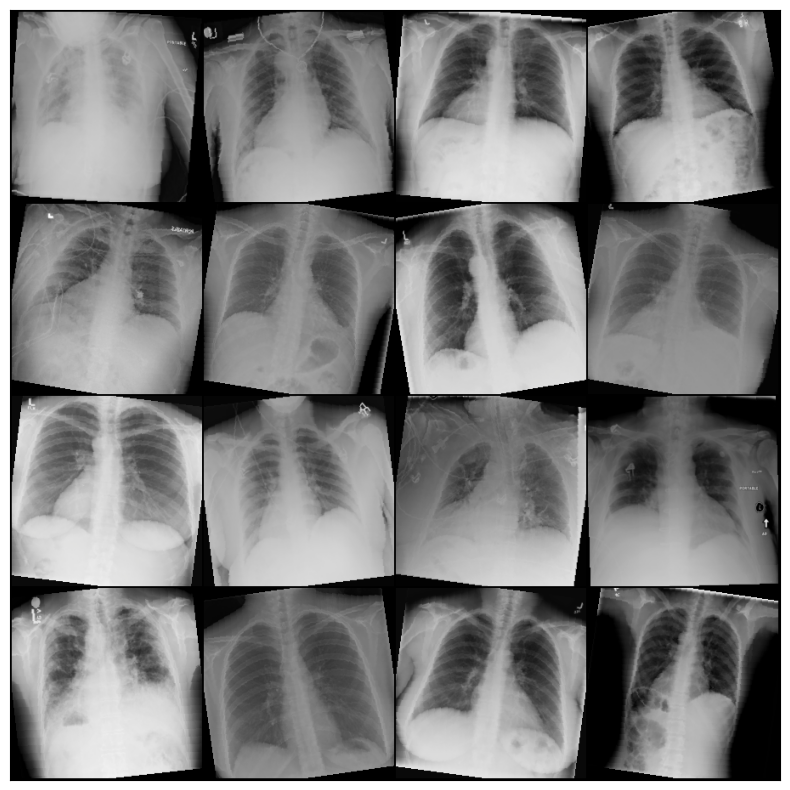

In [9]:
show_train_dl = DataLoader(train_dataset, batch_size=16, shuffle=True)
show_val_dl = DataLoader(val_dataset, batch_size=16, shuffle=False)
show_test_dl = DataLoader(test_dataset, batch_size=16, shuffle=False)

def Show_Sample(dl):
    _,ax = plt.subplots(figsize=(12,10))
    imgs,labels = next(iter(dl))
    imgs = denormalize(imgs)
    ax.set_yticks([])
    ax.set_xticks([])
    grid = make_grid(imgs, 4).permute(1, 2, 0).numpy()


    ax.imshow(grid)
    

Show_Sample(show_train_dl)

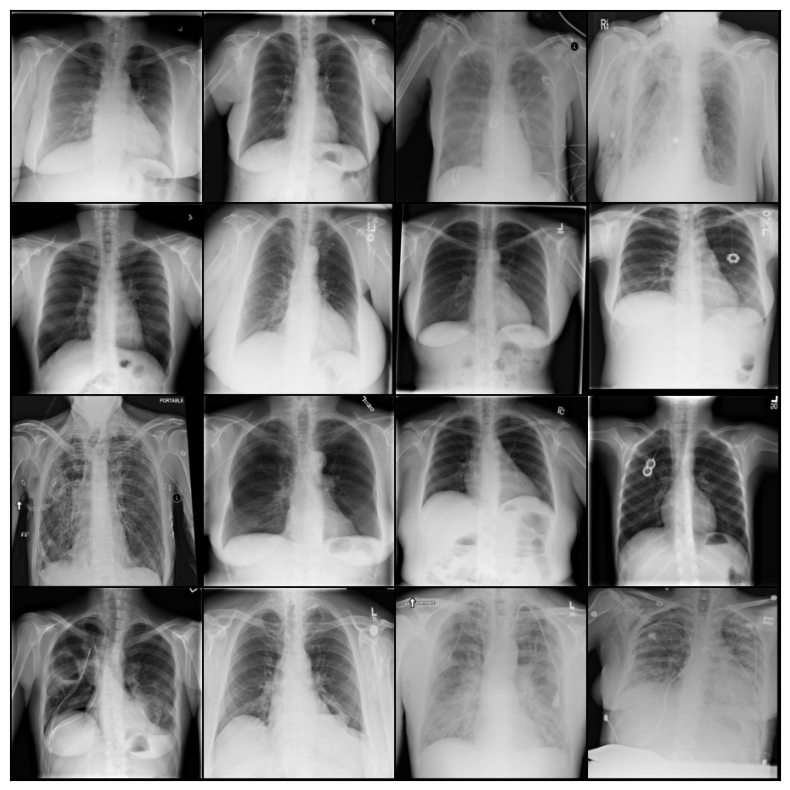

In [10]:
Show_Sample(show_val_dl)

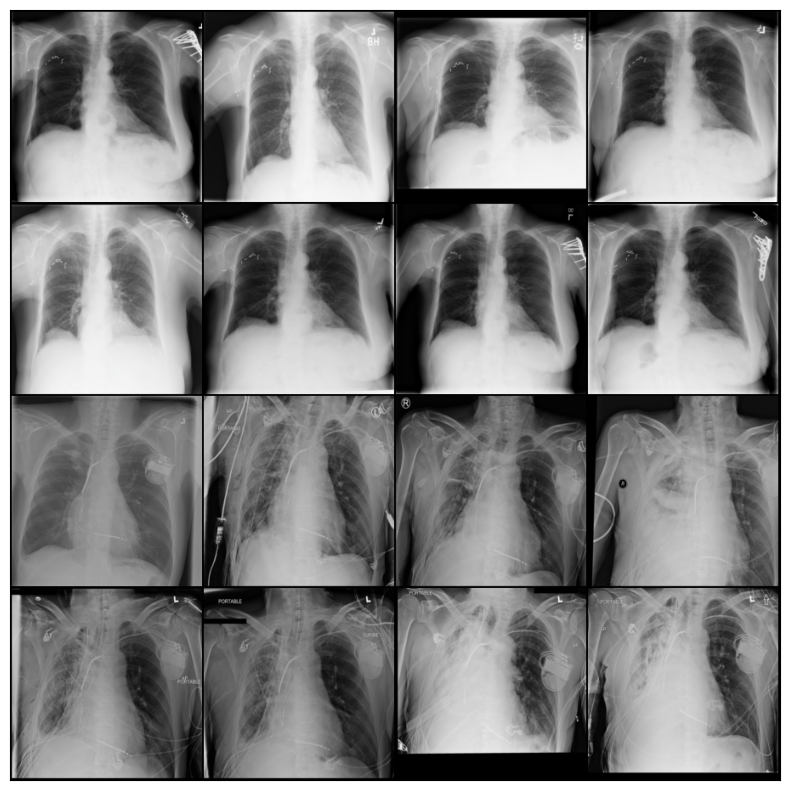

In [11]:
Show_Sample(show_test_dl)

In [12]:
small_train = Subset(train_dataset, range(2000))
small_val   = Subset(val_dataset,   range(500))

small_train_dl = DataLoader(small_train, batch_size=32, shuffle=True,num_workers=0, pin_memory=True)
small_val_dl   = DataLoader(small_val,   batch_size=32, shuffle=False,num_workers=0, pin_memory=True)

In [ ]:
def Show_Curves(model_history):
    train_loss_hist = [x["train_loss"] for x in model_history]
    val_loss_hist   = [x["val_loss" ] for x in model_history]
    train_auc_hist  = [x["train_auc"  ] for x in model_history]
    val_auc_hist    = [x["val_auc"  ] for x in model_history]

    _, ax = plt.subplots(1, 2, figsize=(14, 5))

    # ── Loss Curve ──────────────────────────────────────────────────────────
    ax[0].plot(train_loss_hist,     label="Train",      linewidth=2)
    ax[0].plot(val_loss_hist, label="Validation",  linewidth=2, linestyle="--")
    ax[0].set_title("Loss Over Epochs", fontsize=13, fontweight="bold")
    ax[0].set_ylabel("Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    # ── AUC Curve ───────────────────────────────────────────────────────
    ax[1].plot(train_auc_hist,     label="Train",      linewidth=2)
    ax[1].plot(val_auc_hist, label="Validation",  linewidth=2, linestyle="--")
    ax[1].set_title("AUC Over Epochs", fontsize=13, fontweight="bold")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
def Show_MCM(labels,preds_binary):

    mcm = multilabel_confusion_matrix(labels, preds_binary)

    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    axes = axes.flatten()

    for i, (matrix, disease) in enumerate(zip(mcm, ALL_DISEASES)):
        sns.heatmap(matrix, 
                    annot=True, 
                    fmt='d',
                    cmap='Blues',
                    ax=axes[i],
                    xticklabels=['Pred 0', 'Pred 1'],
                    yticklabels=['True 0', 'True 1'])
        axes[i].set_title(disease, fontsize=10)

    fig.delaxes(axes[14])
    plt.suptitle('Confusion Matrix per Disease', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
def model_predict(model,test_dl):
    all_imgs = []
    all_preds = []
    all_labels = []

    model.eval()

    with no_grad():
        for batch in test_dl:
            imgs,labels = batch
            imgs = imgs.to(dev)
            labels = labels.to(dev)
            outputs = model(imgs)

            
            probs = sigmoid(outputs)
            
            all_imgs.extend(imgs.cpu())
            all_preds.append(probs.detach().cpu())
            all_labels.append(labels.detach().cpu())
        
    all_preds = cat(all_preds).numpy()
    all_labels = cat(all_labels).numpy()


    return (all_imgs,all_labels,all_preds)

In [ ]:
def fit_predict (model_name,model_weights,all_splitted_data,learning_rate =LR , show_logs=True , show_results=True):

    
    model = model_name(model_weights.DEFAULT)
    model.classifier = nn.Linear(model.classifier.in_features,NUM_OF_CLASSES).to(dev)
    model = model.to(dev)
    critirion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHTS)
    opt = AdamW(model.parameters(),lr=learning_rate)

    save_best_model_path = os.path.join(SAVED_MODELS_FOLDER,f'{model._get_name()}_best_model.pth')

    if show_logs:
        print(f"{model._get_name()} Is Running")

    history = []
    counter = 0
    for epoch in range(EPOCHS):
        train_auc = None

        all_train_loss = []
        all_train_preds=[]
        all_train_labels = []

        model.train()

        for batch in tqdm(all_splitted_data[0],desc=f"Epoch: {epoch+1}/{EPOCHS}" if show_logs else None):
            imgs,labels = batch
            imgs = imgs.to(dev)
            labels = labels.to(dev)

            outputs = model(imgs)
            loss = critirion(outputs,labels)
            loss.backward()
            opt.step()
            opt.zero_grad()
            
            all_train_loss.append(loss.item())

            probs = sigmoid(outputs)
            all_train_preds.append(probs.detach().cpu())
            all_train_labels.append(labels.detach().cpu())
            
        all_train_preds = cat(all_train_preds).numpy()
        all_train_labels = cat(all_train_labels).numpy()

        valid_classes = [i for i in range(NUM_OF_CLASSES) 
                        if all_train_labels[:, i].sum() > 0]

        train_auc = roc_auc_score(all_train_labels[:, valid_classes]
                                ,all_train_preds[:, valid_classes],average="macro")
        
        train_loss = sum(all_train_loss) / len(all_train_loss)

        # --------EVAL----------

        val_auc = None
        
        all_val_loss = []
        all_val_preds=[]
        all_val_labels = []

        model.eval()
        with no_grad():
            for batch in all_splitted_data[1]:
                imgs,labels = batch
                imgs = imgs.to(dev)
                labels = labels.to(dev)
                outputs = model(imgs)
                loss = critirion(outputs,labels)
                all_val_loss.append(loss.item())

                probs = sigmoid(outputs)
                all_val_preds.append(probs.detach().cpu())
                all_val_labels.append(labels.detach().cpu())


        val_loss = sum(all_val_loss) / len(all_val_loss)

        all_val_preds = cat(all_val_preds).numpy()
        all_val_labels = cat(all_val_labels).numpy()

        valid_classes = [i for i in range(NUM_OF_CLASSES) 
                        if all_val_labels[:, i].sum() > 0]

        val_auc = roc_auc_score(all_val_labels[:, valid_classes],
                                all_val_preds[:, valid_classes],
                                average="macro")

        # END of the evaluation

        if show_logs:
            print(f"Train_Loss: {train_loss:.4f} ── Val_Loss: {val_loss:.4f} | Train_AUC: {train_auc:.4f} | Val_AUC: {val_auc:.4f}")

            print("Classes with no positive samples in val:")
            for i, disease in enumerate(ALL_DISEASES):
                if all_val_labels[:, i].sum() == 0:
                    print(f"  {disease}")

        history.append({
            "train_loss": train_loss,
            "val_loss" : val_loss,
            "train_auc" : train_auc,
            "val_auc"  : val_auc,
        })

        
        if val_auc > BEST_VAL_AUC:
            BEST_VAL_AUC = val_auc
            counter = 0
            save(model.state_dict(), save_best_model_path )  # save best weights
        else:
            counter += 1
            if counter >= PATIENCE:
                if show_logs:
                    print("Early Stopping!!")
                break

    # End of All Epochs
    
    if show_results:
        model.load_state_dict(load(save_best_model_path,map_location=dev))
        print("Model Successfuly Loaded")
        Show_Curves(history)

        # Predicting
        all_imgs,all_labels,all_preds = model_predict(model,test_dl=all_splitted_data[2])
        print("Preds:", all_preds[:10])
        print("Labels:",all_labels[:10])

        valid_classes = [i for i in range(NUM_OF_CLASSES) 
                if all_labels[:, i].sum() > 0]

        all_preds_binary = (all_preds > 0.5).astype(int)

        results_row = {
            'Model'    : model._get_name(),
            'AUC'      : np.round(roc_auc_score(all_labels[:, valid_classes], all_preds[:, valid_classes] ,average="macro"), 4),
            'F1'       : np.round(f1_score(all_labels, all_preds_binary, average='macro', zero_division=0), 4),
            'Precision': np.round(precision_score(all_labels, all_preds_binary, average='macro', zero_division=0), 4),
            'Recall'   : np.round(recall_score(all_labels, all_preds_binary, average='macro', zero_division=0), 4),
        }

        Show_MCM(all_labels,all_preds_binary)
        
        results_path = 'C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\My Reserch Papers\chest-xray-multilabel-classification\results\All_Models_Results.csv'
        if os.path.exists(results_path):
            results_df = pd.read_csv(results_path)
        else:
            results_df = pd.DataFrame()

        results_df = pd.concat([results_df, pd.DataFrame([results_row])], ignore_index=True)
        results_df.to_csv(results_path, index=False)
        print(results_df)
        
        save({
            'model_state' : model.state_dict(),
            'test_preds'  : all_preds_binary,
            'test_probs'  : all_preds, 
            'test_labels' : all_labels,
            'all_imgs' : all_imgs,
            }, save_best_model_path )

In [ ]:
fit_predict(densenet121,DenseNet121_Weights,[small_train_dl,small_val_dl,small_val_dl])